# House Prices – Thực nghiệm MLP bằng PyTorch

1. Đọc và tiền xử lý dữ liệu
2. Tách Input / Output
3. Xây dựng MLP và hàm huấn luyện dùng chung
4. Thực hiện 4 thí nghiệm
5. So sánh kết quả
6. Chọn mô hình tốt nhất
7. Dự đoán test và tạo `submission.csv`


## 1. Import thư viện

In [26]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


## 2. Đọc dữ liệu

In [27]:
TRAIN_PATH = "/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv"
TEST_PATH = "/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv"
SAMPLE_PATH = "/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Test shape :", test.shape)

display(train.head())


Train shape: (1460, 81)
Test shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Tiền xử lý dữ liệu

Giữ nguyên cách xử lý trong các notebook PyTorch gốc:

- Bỏ `Id`
- Bỏ các cột có nhiều missing: `Alley`, `PoolQC`, `Fence`, `MiscFeature`
- Categorical: điền missing bằng mode
- Numerical: điền missing bằng mean
- One-Hot Encoding
- Ghép train và test trước khi encoding để bảo đảm hai tập có cùng tập cột


In [28]:
# 3.1. Xóa Id và các cột nhiều missing
to_drop = ["Id", "Alley", "PoolQC", "Fence", "MiscFeature"]

train = train.drop(columns=to_drop, errors="ignore").copy()
test = test.drop(columns=to_drop, errors="ignore").copy()

# 3.2. Xác định kiểu dữ liệu
categorical_cols = train.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = test.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Số categorical columns:", len(categorical_cols))
print("Số numerical columns :", len(numerical_cols))

# 3.3. Điền missing
for col in categorical_cols:
    mode_value = train[col].mode()[0]
    train[col] = train[col].fillna(mode_value)
    if col in test.columns:
        test[col] = test[col].fillna(mode_value)

for col in numerical_cols:
    if col in train.columns and col != "SalePrice":
        train[col] = train[col].fillna(train[col].mean())
    if col in test.columns:
        test[col] = test[col].fillna(test[col].mean())

# 3.4. One-Hot Encoding
final_df = pd.concat([train, test], axis=0, ignore_index=True)

for col in categorical_cols:
    encoded = pd.get_dummies(final_df[col], prefix=col, drop_first=True)
    final_df = pd.concat(
        [final_df.drop(columns=[col]), encoded],
        axis=1
    )

final_df = final_df.loc[:, ~final_df.columns.duplicated()]

# Chia lại train/test
n_train = len(train)

df_train = final_df.iloc[:n_train].copy()
df_test = final_df.iloc[n_train:].copy()

# SalePrice chỉ có ở train
df_test = df_test.drop(columns=["SalePrice"], errors="ignore")

# Ép kiểu để PyTorch sử dụng được
X_all = df_train.drop(columns=["SalePrice"]).astype("float32")
y_all = df_train["SalePrice"].astype("float32")
X_test_all = df_test.astype("float32")

print("\nX_all      :", X_all.shape)
print("y_all      :", y_all.shape)
print("X_test_all :", X_test_all.shape)


Số categorical columns: 39
Số numerical columns : 36

X_all      : (1460, 235)
y_all      : (1460,)
X_test_all : (1459, 235)


## 4. Kiểm tra dữ liệu sau tiền xử lý

In [29]:
print("Missing trong X_all:", X_all.isnull().sum().sum())
print("Missing trong X_test_all:", X_test_all.isnull().sum().sum())
print("Kiểu dữ liệu X:", X_all.dtypes.value_counts().to_dict())

print("\nSalePrice:")
display(y_all.describe())


Missing trong X_all: 0
Missing trong X_test_all: 0
Kiểu dữ liệu X: {dtype('float32'): 235}

SalePrice:


count      1460.0000
mean     180921.1875
std       79442.5000
min       34900.0000
25%      129975.0000
50%      163000.0000
75%      214000.0000
max      755000.0000
Name: SalePrice, dtype: float64

## 5. Tách Numerical và Categorical Features

Sau One-Hot Encoding, các categorical features trở thành các cột số 0/1.

- **Experiment 1:** tất cả features
- **Experiment 2:** chỉ numerical features
- **Experiment 3:** chỉ các features sinh ra từ categorical features
- **Experiment 4:** chọn features có `Mean > Median` theo đúng notebook gốc


In [30]:
# Numerical columns sau preprocessing
num_cols = [
    col for col in numerical_cols
    if col in X_all.columns and col != "SalePrice"
]

# Các cột còn lại được xem là categorical-derived features
cat_cols = [col for col in X_all.columns if col not in num_cols]

print("Numerical features:", len(num_cols))
print("Categorical-derived features:", len(cat_cols))
print("Total features:", X_all.shape[1])


Numerical features: 36
Categorical-derived features: 199
Total features: 235


## 6. Xây dựng kiến trúc MLP

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 50)
        nn.init.kaiming_uniform_(self.fc1.weight, nonlinearity="relu")

        self.fc2 = nn.Linear(50, 25)
        nn.init.kaiming_uniform_(self.fc2.weight, nonlinearity="relu")

        self.fc3 = nn.Linear(25, 50)
        nn.init.kaiming_uniform_(self.fc3.weight, nonlinearity="relu")

        self.out = nn.Linear(50, 1)
        nn.init.kaiming_uniform_(self.out.weight)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.out(x)


class RMSELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()

    def forward(self, y_pred, y_true):
        return torch.sqrt(self.mse(y_pred, y_true))


## 7. Hàm thực hiện một thí nghiệm

Mỗi thí nghiệm:

- Chia dữ liệu thành 75% train và 25% validation
- `batch_size = 10`
- Optimizer: `Adamax`
- Loss: RMSE
- `epochs = 200`
- Lưu lại validation RMSE để so sánh


In [32]:
def run_experiment(
    X_tr,
    y_tr,
    X_te,
    exp_name="Experiment",
    epochs=200,
    batch_size=10
):
    print("\n" + "=" * 65)
    print(exp_name)
    print("Số lượng đặc trưng:", X_tr.shape[1])
    print("=" * 65)

    # DataFrame -> Tensor
    X_tensor = torch.tensor(X_tr.values, dtype=torch.float32)
    y_tensor = torch.tensor(
        y_tr.values,
        dtype=torch.float32
    ).view(-1, 1)

    # Train / Validation
    X_train_t, X_val_t, y_train_t, y_val_t = train_test_split(
        X_tensor,
        y_tensor,
        test_size=0.25,
        random_state=SEED
    )

    X_train_t = X_train_t.to(DEVICE)
    y_train_t = y_train_t.to(DEVICE)
    X_val_t = X_val_t.to(DEVICE)
    y_val_t = y_val_t.to(DEVICE)

    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(X_val_t, y_val_t),
        batch_size=batch_size,
        shuffle=False
    )

    model = MLP(input_dim=X_tr.shape[1]).to(DEVICE)

    criterion = RMSELoss()
    optimizer = torch.optim.Adamax(model.parameters())

    history = {
        "train_rmse": [],
        "val_rmse": []
    }

    for epoch in range(epochs):
        # -----------------
        # Training
        # -----------------
        model.train()
        train_squared_error = 0.0
        train_count = 0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()

            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)

            loss.backward()
            optimizer.step()

            train_squared_error += (
                torch.sum((predictions - batch_y) ** 2).item()
            )
            train_count += batch_X.size(0)

        train_rmse = np.sqrt(train_squared_error / train_count)

        # -----------------
        # Validation
        # -----------------
        model.eval()
        val_squared_error = 0.0
        val_count = 0

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                val_preds = model(batch_X)

                val_squared_error += (
                    torch.sum((val_preds - batch_y) ** 2).item()
                )
                val_count += batch_X.size(0)

        val_rmse = np.sqrt(val_squared_error / val_count)

        history["train_rmse"].append(train_rmse)
        history["val_rmse"].append(val_rmse)

        if (epoch + 1) % 200 == 0 or epoch == 0:
            print(
                f"Epoch {epoch + 1:4d}/{epochs} | "
                f"Train RMSE: {train_rmse:.4f} | "
                f"Val RMSE: {val_rmse:.4f}"
            )

    return model, X_te.copy(), history, float(history["val_rmse"][-1])


## 8. Thí nghiệm 1 – Tất cả đặc trưng (Baseline)

In [33]:
X_tr_exp1 = X_all.copy()
X_te_exp1 = X_test_all.copy()

model_exp1, X_test_exp1, history_exp1, score_exp1 = run_experiment(
    X_tr_exp1,
    y_all,
    X_te_exp1,
    exp_name="Thí nghiệm 1: Tất cả đặc trưng (Baseline)"
)



Thí nghiệm 1: Tất cả đặc trưng (Baseline)
Số lượng đặc trưng: 235
Epoch    1/200 | Train RMSE: 165218.8624 | Val RMSE: 93872.3040
Epoch  200/200 | Train RMSE: 31805.9176 | Val RMSE: 34288.8811


## 9. Thí nghiệm 2 – Chỉ Numerical Features

In [34]:
X_tr_exp2 = X_all[num_cols].copy()
X_te_exp2 = X_test_all[num_cols].copy()

model_exp2, X_test_exp2, history_exp2, score_exp2 = run_experiment(
    X_tr_exp2,
    y_all,
    X_te_exp2,
    exp_name="Thí nghiệm 2: Chỉ chọn Numerical Features"
)



Thí nghiệm 2: Chỉ chọn Numerical Features
Số lượng đặc trưng: 36
Epoch    1/200 | Train RMSE: 144308.2637 | Val RMSE: 76179.4141
Epoch  200/200 | Train RMSE: 36656.1846 | Val RMSE: 35945.7483


## 10. Thí nghiệm 3 – Chỉ Categorical-derived Features

In [35]:
X_tr_exp3 = X_all[cat_cols].copy()
X_te_exp3 = X_test_all[cat_cols].copy()

model_exp3, X_test_exp3, history_exp3, score_exp3 = run_experiment(
    X_tr_exp3,
    y_all,
    X_te_exp3,
    exp_name="Thí nghiệm 3: Chỉ chọn Categorical Features"
)



Thí nghiệm 3: Chỉ chọn Categorical Features
Số lượng đặc trưng: 199
Epoch    1/200 | Train RMSE: 197552.5887 | Val RMSE: 196543.8887
Epoch  200/200 | Train RMSE: 30675.7266 | Val RMSE: 38895.1183


## 11. Thí nghiệm 4 – Mean > Median

In [36]:
# Chọn các feature có Mean lớn hơn Median của toàn bộ Mean
feature_means = X_all.mean(axis=0)
threshold = feature_means.median()

selected_cols_exp4 = feature_means[
    feature_means > threshold
].index.tolist()

X_tr_exp4 = X_all[selected_cols_exp4].copy()
X_te_exp4 = X_test_all[selected_cols_exp4].copy()

print("Threshold:", threshold)
print("Số feature được chọn:", len(selected_cols_exp4))

model_exp4, X_test_exp4, history_exp4, score_exp4 = run_experiment(
    X_tr_exp4,
    y_all,
    X_te_exp4,
    exp_name="Thí nghiệm 4: Mean > Median threshold"
)


Threshold: 0.04178082197904587
Số feature được chọn: 117

Thí nghiệm 4: Mean > Median threshold
Số lượng đặc trưng: 117
Epoch    1/200 | Train RMSE: 154634.3885 | Val RMSE: 85125.7105
Epoch  200/200 | Train RMSE: 39009.9928 | Val RMSE: 33092.0493


## 12. So sánh 4 thí nghiệm

In [37]:
results = pd.DataFrame({
    "Experiment": [
        "TN1 - All Features",
        "TN2 - Numerical Only",
        "TN3 - Categorical Only",
        "TN4 - Mean > Median"
    ],
    "Num Features": [
        X_tr_exp1.shape[1],
        X_tr_exp2.shape[1],
        X_tr_exp3.shape[1],
        X_tr_exp4.shape[1]
    ],
    "Validation RMSE": [
        score_exp1,
        score_exp2,
        score_exp3,
        score_exp4
    ]
})

results = results.sort_values(
    by="Validation RMSE",
    ascending=True
).reset_index(drop=True)

display(results)

best_experiment = results.loc[0, "Experiment"]
best_score = results.loc[0, "Validation RMSE"]

print(f"\nMô hình tốt nhất: {best_experiment}")
print(f"Validation RMSE: {best_score:.4f}")


,Experiment,Num Features,Validation RMSE
0,TN4 - Mean > Median,117,33092.049316
1,TN1 - All Features,235,34288.881114
2,TN2 - Numerical Only,36,35945.748272
3,TN3 - Categorical Only,199,38895.118269



Mô hình tốt nhất: TN4 - Mean > Median
Validation RMSE: 33092.0493


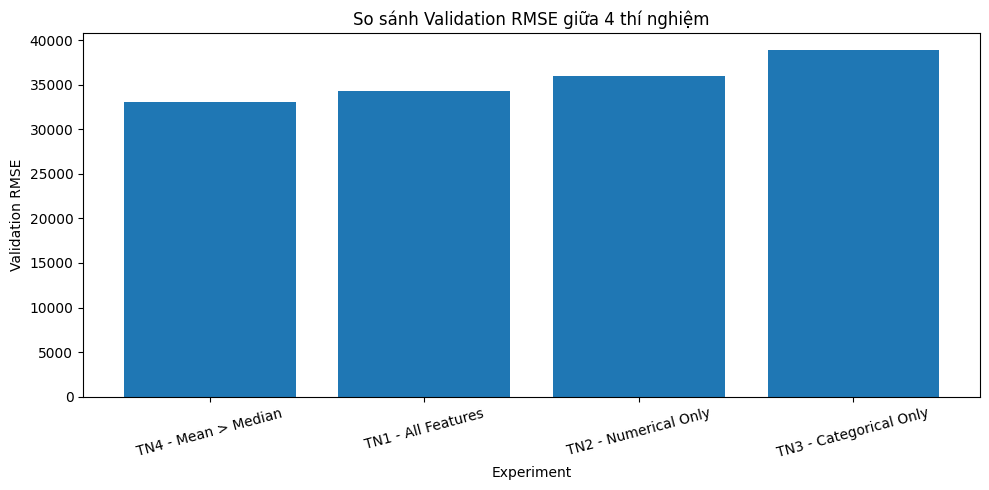

In [38]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Experiment"],
    results["Validation RMSE"]
)

plt.ylabel("Validation RMSE")
plt.xlabel("Experiment")
plt.title("So sánh Validation RMSE giữa 4 thí nghiệm")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 13. Chọn mô hình tốt nhất

In [39]:
models = {
    "TN1 - All Features": model_exp1,
    "TN2 - Numerical Only": model_exp2,
    "TN3 - Categorical Only": model_exp3,
    "TN4 - Mean > Median": model_exp4
}

test_sets = {
    "TN1 - All Features": X_test_exp1,
    "TN2 - Numerical Only": X_test_exp2,
    "TN3 - Categorical Only": X_test_exp3,
    "TN4 - Mean > Median": X_test_exp4
}

histories = {
    "TN1 - All Features": history_exp1,
    "TN2 - Numerical Only": history_exp2,
    "TN3 - Categorical Only": history_exp3,
    "TN4 - Mean > Median": history_exp4
}

best_model = models[best_experiment]
best_X_test = test_sets[best_experiment]

print("Best model:", best_experiment)
print("Number of features:", best_X_test.shape[1])


Best model: TN4 - Mean > Median
Number of features: 117


## 14. Vẽ Learning Curve của mô hình tốt nhất

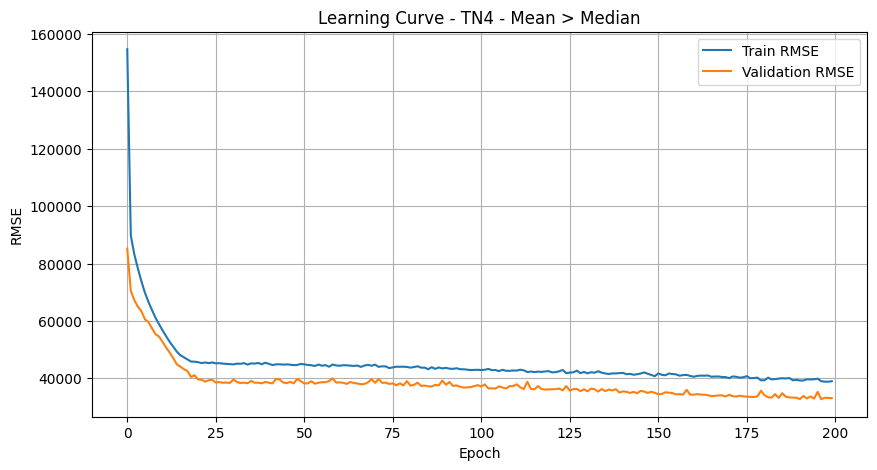

In [40]:
best_history = histories[best_experiment]

plt.figure(figsize=(10, 5))
plt.plot(best_history["train_rmse"], label="Train RMSE")
plt.plot(best_history["val_rmse"], label="Validation RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title(f"Learning Curve - {best_experiment}")
plt.legend()
plt.grid(True)
plt.show()


## 15. Dự đoán trên Test Set

Sau khi chọn mô hình có Validation RMSE nhỏ nhất, sử dụng mô hình đó để dự đoán `SalePrice` trên `test.csv`.


In [41]:
best_model.eval()

X_test_tensor = torch.tensor(
    best_X_test.values,
    dtype=torch.float32
).to(DEVICE)

with torch.no_grad():
    final_preds = best_model(X_test_tensor).cpu().numpy().reshape(-1)

print("Prediction shape:", final_preds.shape)
print("Min prediction :", final_preds.min())
print("Max prediction :", final_preds.max())
print("Mean prediction:", final_preds.mean())


Prediction shape: (1459,)
Min prediction : 63962.082
Max prediction : 528348.25
Mean prediction: 186233.2


## 16. Kiểm tra kết quả dự đoán

In [42]:
print("NaN     :", np.isnan(final_preds).sum())
print("Inf     :", np.isinf(final_preds).sum())
print("Negative:", (final_preds < 0).sum())

prediction_summary = pd.Series(final_preds).describe()
display(prediction_summary)


NaN     : 0
Inf     : 0
Negative: 0


count      1459.000000
mean     186233.203125
std       73265.781250
min       63962.082031
25%      136797.789062
50%      167960.984375
75%      216255.312500
max      528348.250000
dtype: float64

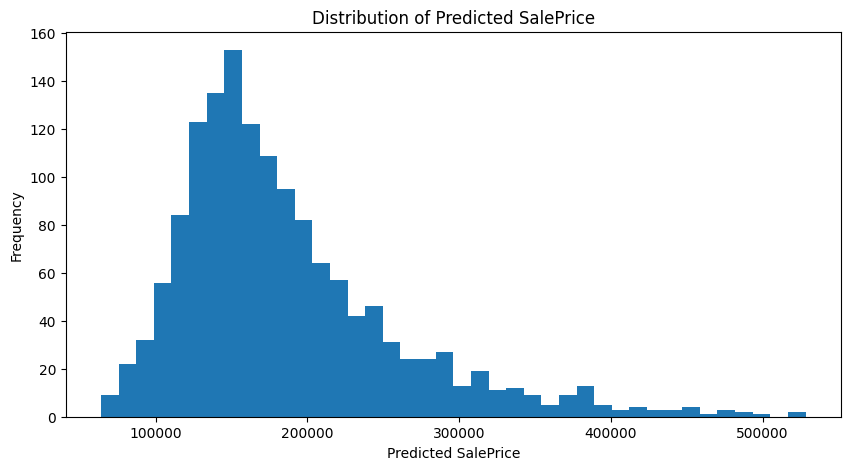

In [43]:
plt.figure(figsize=(10, 5))
plt.hist(final_preds, bins=40)
plt.xlabel("Predicted SalePrice")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted SalePrice")
plt.show()


## 17. Tạo file submission

File submission của House Prices gồm đúng 2 cột:

- `Id`
- `SalePrice`


In [44]:
# Đọc Id gốc từ test
test_ids = pd.read_csv(TEST_PATH)["Id"]

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": final_preds
})

submission.to_csv("submission.csv", index=False)

print("Submission shape:", submission.shape)
display(submission.head())


Submission shape: (1459, 2)


,Id,SalePrice
0,1461,152853.593750
1,1462,77834.929688
2,1463,203802.875000
3,1464,199271.531250
4,1465,184752.656250


## 18. Kiểm tra submission cuối cùng

In [45]:
print("Columns:", submission.columns.tolist())
print("Rows   :", len(submission))

print("\nMissing values:")
print(submission.isnull().sum())

print("\nDuplicate Id:", submission["Id"].duplicated().sum())
print("Negative SalePrice:", (submission["SalePrice"] < 0).sum())


Columns: ['Id', 'SalePrice']
Rows   : 1459

Missing values:
Id           0
SalePrice    0
dtype: int64

Duplicate Id: 0
Negative SalePrice: 0


## 19. Kết luận

Quy trình cuối cùng:

`train.csv / test.csv`
→ tiền xử lý
→ One-Hot Encoding
→ tạo 4 tập feature
→ huấn luyện 4 MLP
→ so sánh Validation RMSE
→ chọn mô hình tốt nhất
→ dự đoán test
→ tạo `submission.csv`.

### 4 thí nghiệm

| Thí nghiệm | Feature |
|---|---|
| TN1 | Tất cả features |
| TN2 | Chỉ Numerical |
| TN3 | Chỉ Categorical-derived |
| TN4 | Mean > Median |

**Mô hình được chọn tự động là mô hình có Validation RMSE nhỏ nhất.**
